# SK이노베이션 주가 시계열 분석

2021-07~2024-12 수정 종가를 수집·캐시합니다. 마지막 60거래일을 최종 검증, 그 직전 30거래일을 모델 선택에 사용합니다. ARIMA 후보와 직전 종가 유지 기준 모델을 비교하며 실제 거래일에 예측과 구간을 정렬합니다. 60스텝은 60거래 관측치이며 달력 60일이 아닙니다. 투자 의사결정의 효과를 검증한 프로젝트로 표현하지 않습니다.

원본 CSV는 변경하지 않습니다. 실행 결과는 `outputs/`에 저장됩니다.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
SEED = 2026

def preprocessing(frame):
    categorical = frame.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    numerical = [c for c in frame if c not in categorical]
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median', add_indicator=True), numerical),
        ('cat', Pipeline([('fill', SimpleImputer(strategy='constant', fill_value='Unknown')),
                          ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical)
    ])

def save_submission(sample, ids, target, prediction):
    assert list(sample.columns) == [ids.name, target], '제출 열 확인 필요'
    assert len(ids) == len(prediction) == len(sample)
    assert sample[ids.name].astype(str).tolist() == ids.astype(str).tolist(), '제출 ID 순서 불일치'
    assert np.isfinite(prediction).all()
    result = sample.copy()
    result[target] = prediction
    result.to_csv(OUT / 'submission.csv', index=False)
    return result



## 데이터 수집과 고정 기간

In [2]:
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
CACHE = Path('data/sk_innovation_close.csv')
CACHE.parent.mkdir(exist_ok=True)
if CACHE.exists():
    prices = pd.read_csv(CACHE, parse_dates=['Date']).set_index('Date')['Close']
else:
    downloaded = yf.download('096770.KS', start='2021-07-01', end='2025-01-01', auto_adjust=True, progress=False)
    if downloaded.empty:
        raise RuntimeError('Yahoo Finance 수집 실패. data/sk_innovation_close.csv를 Date,Close 열로 준비하세요.')
    prices = downloaded['Close']
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]
    prices.rename('Close').to_frame().to_csv(CACHE, index_label='Date')
prices = prices.sort_index().dropna()
prices = prices.loc['2021-07-01':'2024-12-31']
assert prices.index.is_unique and len(prices)>300 and prices.gt(0).all()
print('수정 종가:', len(prices), prices.index.min(), prices.index.max())


수정 종가: 858 2021-07-01 00:00:00 2024-12-30 00:00:00


## 기술통계와 이동평균

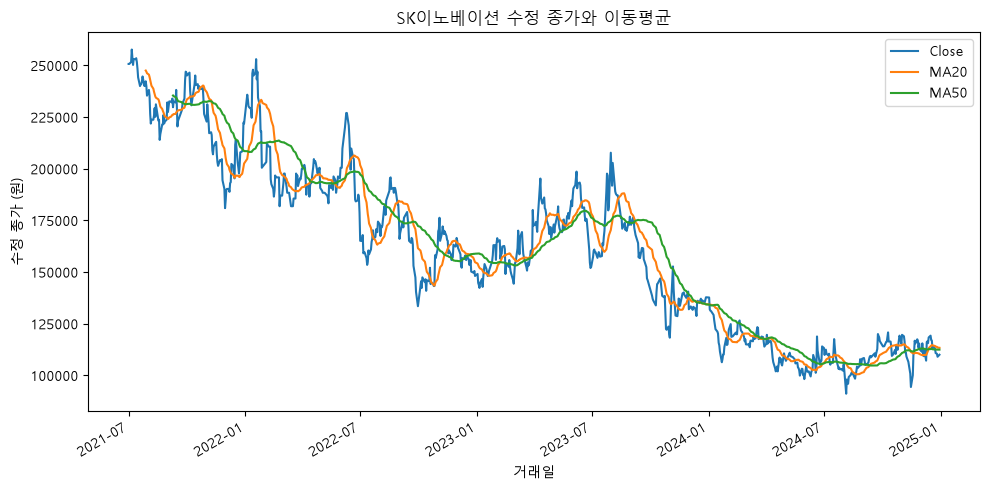

,일별 수익률
count,857.000000
mean,-0.000573
std,0.028036
min,-0.110259
25%,-0.016030
50%,-0.001862
75%,0.012115
max,0.155683


In [3]:
eda = pd.DataFrame({'Close': prices, 'MA20': prices.rolling(20).mean(), 'MA50': prices.rolling(50).mean()})
ax = eda.plot(figsize=(10,5), title='SK이노베이션 수정 종가와 이동평균')
ax.set(ylabel='수정 종가 (원)', xlabel='거래일'); plt.tight_layout(); plt.savefig(OUT / 'price_history.png'); plt.show(); plt.close()
returns = prices.pct_change().dropna()
display(returns.describe().to_frame('일별 수익률'))


## 순차 평가: 직전 30거래일 선택용, 마지막 60거래일 최종 홀드아웃

C:\Users\Admin\AppData\Local\Temp\ipykernel_26120\43107624.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  display(pd.DataFrame([{'series': 'price', 'adf_p': adfuller(fit)[1]},
C:\Users\Admin\AppData\Local\Temp\ipykernel_26120\43107624.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  {'series': 'first_difference', 'adf_p': adfuller(fit.diff().dropna())[1]}]))


,series,adf_p
0,price,0.359313
1,first_difference,0.000000


,order,selection_rmse
1,"(1, 1, 0)",8664.207183
0,"(0, 1, 0)",8665.953529
2,"(5, 1, 0)",8768.063127


{
  "order": [
    1,
    1,
    0
  ],
  "forecast_steps": 60,
  "holdout_rmse": 5191.59200610603,
  "baseline_rmse": 5192.534354314244,
  "holdout_mae": 3822.155630569779,
  "unit": "KRW adjusted close",
  "period": [
    "2021-07-01",
    "2024-12-30"
  ]
}


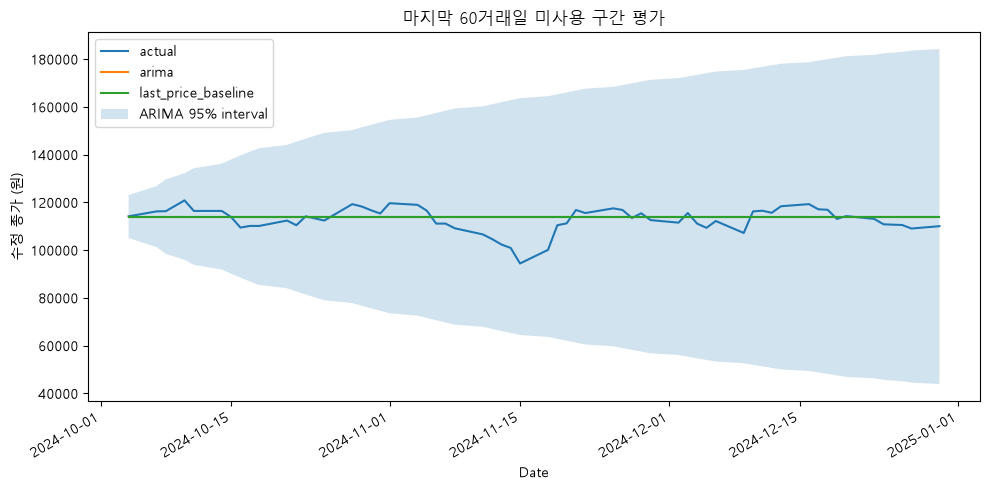

,development residuals
count,798.000000
mean,142.378788
std,10000.009778
min,-17675.078125
25%,-2347.719832
50%,-197.319267
75%,1907.409457
max,250707.000000


학습 구간에서 결정한 모델을 마지막 60거래일에 평가했다. 실제 거래일 인덱스로 그래프를 정렬했다.
한계: 단일 종목과 단일 평가 구간이며 외부 사건을 반영하지 않는다. 예측 구간은 모델 가정에 의존한다.
투자 수익이나 매매 결정을 검증한 분석이 아니다. 종가 기준 모델과의 예측 오차 비교로 해석한다.


In [4]:
development, holdout = prices.iloc[:-60], prices.iloc[-60:]
fit, selection = development.iloc[:-30], development.iloc[-30:]
display(pd.DataFrame([{'series': 'price', 'adf_p': adfuller(fit)[1]},
                      {'series': 'first_difference', 'adf_p': adfuller(fit.diff().dropna())[1]}]))
candidate_orders = [(0,1,0), (1,1,0), (5,1,0)]
rows = []
for order in candidate_orders:
    model = ARIMA(fit.to_numpy(), order=order).fit()
    pred = model.forecast(steps=len(selection))
    rows.append({'order': str(order), 'selection_rmse': root_mean_squared_error(selection, pred)})
comparison = pd.DataFrame(rows).sort_values('selection_rmse')
display(comparison)
comparison.to_csv(OUT / 'model_comparison.csv', index=False)
selected_order = candidate_orders[[str(o) for o in candidate_orders].index(comparison.iloc[0]['order'])]
model = ARIMA(development.to_numpy(), order=selected_order).fit()
forecast = model.get_forecast(steps=len(holdout))
pred = np.asarray(forecast.predicted_mean)
interval = np.asarray(forecast.conf_int())
baseline = np.full(len(holdout), development.iloc[-1])
metrics = {'order': list(selected_order), 'forecast_steps': 60,
           'holdout_rmse': root_mean_squared_error(holdout,pred),
           'baseline_rmse': root_mean_squared_error(holdout,baseline),
           'holdout_mae': mean_absolute_error(holdout,pred), 'unit': 'KRW adjusted close',
           'period': [str(prices.index.min().date()), str(prices.index.max().date())]}
print(json.dumps(metrics, ensure_ascii=False, indent=2))
(OUT / 'metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
result = pd.DataFrame({'actual':holdout, 'arima':pred, 'last_price_baseline':baseline,
                       'lower95':interval[:,0], 'upper95':interval[:,1]},index=holdout.index)
result.to_csv(OUT / 'holdout_predictions.csv')
fig, ax = plt.subplots(figsize=(10,5))
result[['actual','arima','last_price_baseline']].plot(ax=ax)
ax.fill_between(result.index, result.lower95, result.upper95,alpha=.2,label='ARIMA 95% interval')
ax.set(title='마지막 60거래일 미사용 구간 평가',ylabel='수정 종가 (원)'); ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'holdout_forecast.png'); plt.show(); plt.close(fig)
residuals = pd.Series(model.resid)
display(residuals.describe().to_frame('development residuals'))
print('학습 구간에서 결정한 모델을 마지막 60거래일에 평가했다. 실제 거래일 인덱스로 그래프를 정렬했다.')
print('한계: 단일 종목과 단일 평가 구간이며 외부 사건을 반영하지 않는다. 예측 구간은 모델 가정에 의존한다.')
print('투자 수익이나 매매 결정을 검증한 분석이 아니다. 종가 기준 모델과의 예측 오차 비교로 해석한다.')
